import libraries

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from sklearn.model_selection import train_test_split

In [3]:
from my_library.preprocessing import StandardScaler
from my_library.elastic_net_regression import ElasticNetRegressionGradientDescent

In [4]:
from my_library.metrics import (
       mean_squared_error,
       root_mean_squared_error,
       mean_absolute_error,
       r2_score
)

load dataset

In [5]:
df=pd.read_csv("/home/sajid/house-price-prediction/data/train.csv")

In [6]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Handle missing values

Numerical columns 

In [8]:
num_cols=df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col]=df[col].fillna(df[col].median())


Categorical columns

In [9]:
cat_cols=df.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

One Hot Encoding 

In [10]:
df=pd.get_dummies(df,drop_first=True)
df=df.astype(float)

Features and target

In [11]:
X=df.drop("SalePrice",axis=1).values
y=df["SalePrice"].values

Train Test Split

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Feature Scaling

In [13]:
scaler_x=StandardScaler()
X_train=scaler_x.fit_transform(X_train)
X_test=scaler_x.transform(X_test)

scaler_y=StandardScaler()
y_train=scaler_y.fit_transform(y_train)

Train Model

In [14]:
model=ElasticNetRegressionGradientDescent(learning_rate=0.01,epochs=500,alpha=0.1,l1_ratio=0.5)
model.fit(X_train,y_train)

Predictions

In [15]:
y_pred=model.predict(X_test)
y_pred=scaler_y.inverse_transform(y_pred)

Evaluation

In [16]:
print("MSE :", mean_squared_error(y_test, y_pred))

print("RMSE :", root_mean_squared_error(y_test, y_pred))

print("MAE :", mean_absolute_error(y_test, y_pred))

print("R2 Score :", r2_score(y_test, y_pred))

MSE : 1085197607.181532
RMSE : 32942.33760954939
MAE : 18858.809065776164
R2 Score : 0.8585200188533445


Loss Curve

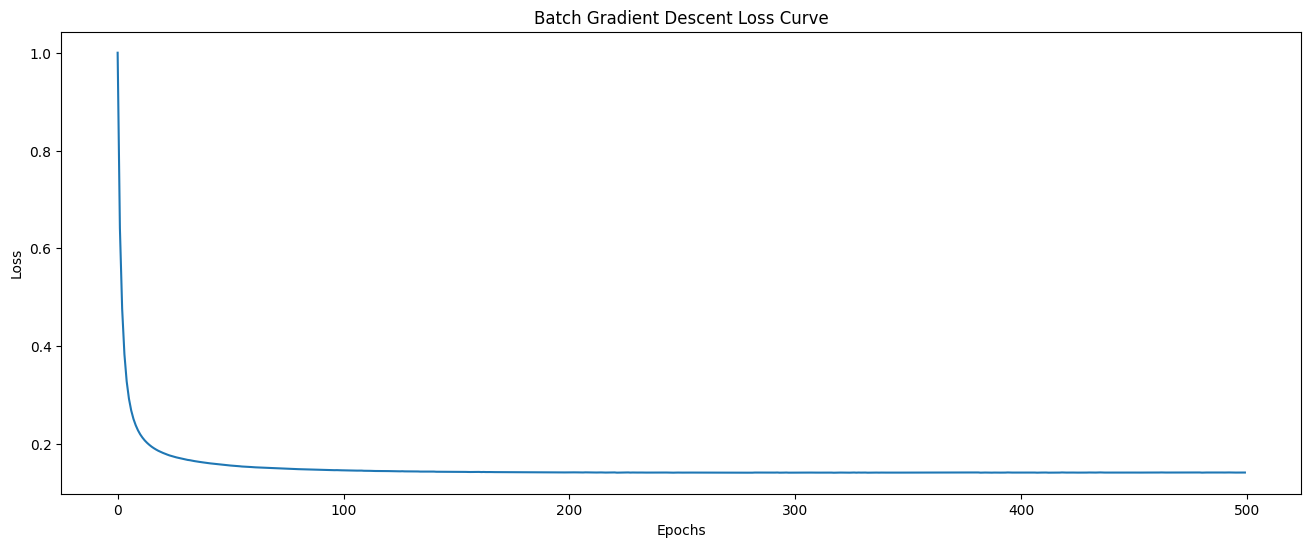

In [17]:
plt.figure(figsize=(16,6))
plt.plot(model.loss)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Batch Gradient Descent Loss Curve")
plt.show()